In [22]:
import pandas as pd
import numpy as np

In [62]:
df = pd.read_csv("C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_10_daily.csv")
df.head()

,Equipment_ID,Date,daily_heating_hours,daily_cooling_hours,daily_off_hours,daily_unknown_hours,daily_runtime_hours,daily_fan_on_hours,fan_runtime_ratio,setpoint_change_count,...,outdoor_hum_skewness,outdoor_hum_kurtosis_excess,outdoor_hum_raw_moment_2,outdoor_hum_raw_moment_3,true_outside_min,true_outside_max,true_outside_mean,true_humidity_mean,outdoor_temp_trend_gradient,temp_gradient_mean
0,timeseries_table_timeseries_table (10),2025-02-13,7.415000,0.0,4.026944,0.010000,7.415000,0.0,0.0,0,...,0.658363,-1.089979,5348.123249,397635.199807,-6.14,4.69,-0.148795,77.963855,-1.617887,23.095106
1,timeseries_table_timeseries_table (10),2025-02-14,16.433333,0.0,7.566667,0.000000,16.433333,0.0,0.0,0,...,1.183828,0.633015,4340.695225,292686.666807,-6.09,8.14,1.823924,65.443038,-1.210176,19.891918
2,timeseries_table_timeseries_table (10),2025-02-15,9.422778,0.0,14.577222,0.000000,9.422778,0.0,0.0,0,...,-2.883211,9.470601,8682.048292,813317.938042,5.21,19.46,9.705000,93.170213,-1.312949,11.241374
3,timeseries_table_timeseries_table (10),2025-02-16,12.932500,0.0,10.997222,0.070278,12.932500,0.0,0.0,0,...,-0.135955,-1.342634,7068.167754,603098.073498,-3.66,13.91,0.905417,83.562500,0.485537,19.990576
4,timeseries_table_timeseries_table (10),2025-02-17,15.641389,0.0,8.358611,0.000000,15.641389,0.0,0.0,1,...,-0.487854,-0.869882,4555.412568,309639.292354,-6.44,2.24,-2.031064,67.457447,0.028764,23.043813


In [63]:
#see preprocessing/eda script
lag_worthy_features = [
    "daily_off_hours",
    "daily_heating_hours",
    "daily_cooling_hours",
    "temp_gradient_mean",
    "setpoint_gap_mean",
    "outdoor_temp_min",
    "outdoor_temp_raw_moment_3",
    "outdoor_temp_mean",
    "outdoor_temp_time_weighted_mean",
    "outdoor_temp_max",
    "outdoor_temp_q25",
    "outdoor_temp_median",
    "outdoor_temp_q75",
    "outdoor_temp_raw_moment_2",
    "setpoint_raw_moment_2",
    "setpoint_mean",
    "setpoint_raw_moment_3",
    "setpoint_time_weighted_mean",
    "daily_unknown_hours",
    "daily_runtime_hours"
]
same_day_features = [
    "true_outside_mean",
    "true_outside_min",
    "true_outside_max",
    "month",
    "outdoor_temp_trend_gradient",
    "true_humidity_mean",
    "Date"
]

#best solution here - light gbm learns what na means - Linear Regression doesnt.
df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
    ["temp_gradient_mean", "setpoint_gap_mean"]
].fillna(0)

df = df[lag_worthy_features + same_day_features]
df = df.dropna()

#filter so that we have the largest group of continuous days not missing values
df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
gaps = df[df['day_gap'] != 1]
groups = (df['day_gap'] > 1).cumsum()
largest_group = groups.value_counts().idxmax()
df = df[groups == largest_group]

In [64]:
lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]

LAG_DAYS = 7

lags = []
for i in range(1, LAG_DAYS + 1):

    s = df[lag_cols_for_shift].shift(i)

    s.columns = [f"{c}_lag_{i}" for c in s.columns]

    lags.append(s)

df_lags = pd.concat([df] + lags, axis=1)


same_day_feats = [f for f in df_lags.columns if f in same_day_features]

lag_feats = [c for c in df_lags.columns if "_lag_" in c]

day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]

final_feature_set = day_only_feats + lag_feats

print(f"\nfinal feature set: {len(final_feature_set)} total")
print(f"  same-day exogenous features: {len(day_only_feats)}")
print(f"  lag features: {len(lag_feats)}")


final feature set: 147 total
  same-day exogenous features: 7
  lag features: 140


In [65]:
window_size = 10

df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
df_lags_dropped = df_lags.dropna() #drop lagged which are missing

dates = df_lags_dropped["Date"]
X = df_lags_dropped[final_feature_set].drop(columns="Date")
y = df_lags_dropped["daily_runtime_hours"]

windows = []



for end in range(window_size, len(y) - 1 + 1):
    start = end - window_size

    X_train = X[start:end]
    y_train = y[start:end]
    
    X_test = X[end:end + 1]
    y_test = y[end:end + 1]

    test_date = dates.iloc[end]
    
    windows.append((X_train, y_train, X_test, y_test, test_date))

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

predictions = []
coefs = []


for X_train, y_train, X_test, y_test, test_date in windows:
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)[0]
    
    predictions.append({
        'y_true': y_test.iloc[0],
        'y_pred': y_pred,
        'date': test_date
    })

    coefs.append(model.coef_)

avg_coef = np.mean(coefs, axis=0)
pred_df = pd.DataFrame(predictions)
print(pred_df)

        y_true     y_pred        date
0     6.365000  11.288932  2025-03-02
1     5.606111   9.855007  2025-03-03
2     3.447778   2.349051  2025-03-04
3     5.992500   3.668125  2025-03-05
4     4.928333   8.586146  2025-03-06
..         ...        ...         ...
214  11.951111  13.800228  2025-10-02
215  12.654167   9.702527  2025-10-03
216  12.560000   9.432311  2025-10-04
217  11.195278   9.412303  2025-10-05
218   7.581944  10.729867  2025-10-06

[219 rows x 3 columns]


In [67]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
print("MSE:",mse) 

print("RMSE:", np.sqrt(mse))

MSE: 12.063310460797787
RMSE: 3.473227671892211


Text(0, 0.5, 'Hours')

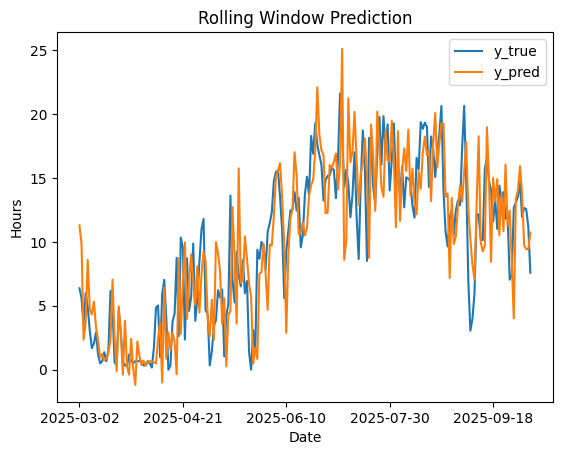

In [69]:
chart = pred_df.set_index('date')[['y_true', 'y_pred']].plot(
    title='Rolling Window Prediction'
)

chart.set_xlabel("Date")
chart.set_ylabel("Hours")

In [31]:
y_true = pred_df["y_true"].to_numpy()
y_pred = pred_df["y_pred"].to_numpy()

In [32]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
)

mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
maxae = np.max(np.abs(y_true - y_pred))

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100.0 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))

mape_val = mape(y_true, y_pred)
smape_val = smape(y_true, y_pred)

r2 = r2_score(y_true, y_pred)
evs = explained_variance_score(y_true, y_pred)

metrics = pd.Series({
    "MSE": mse,
    "RMSE": np.sqrt(mse),
    "MAE": mae,
    "MedianAE": medae,
    "MaxAE": maxae,
    "MAPE (%)": mape_val,
    "sMAPE (%)": smape_val,
    "R2": r2,
    "ExplainedVariance": evs,
})

print("\n=== Model Evaluation (Rolling Predictions) ===")
display(metrics.to_frame("value"))


=== Model Evaluation (Rolling Predictions) ===


,value
MSE,1.000284e+01
RMSE,3.162727e+00
MAE,2.062275e+00
MedianAE,1.232044e+00
MaxAE,1.425811e+01
MAPE (%),4.754041e+08
sMAPE (%),6.353355e+01
R2,7.389728e-01
ExplainedVariance,7.390009e-01


In [38]:
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []
data_count_list = []
dropped_rows_list = []
flagged_list = []

for i in range (1, 101):
    file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
    df = pd.read_csv(file_path)

    #best solution here - light gbm learns what nan means - Linear Regression doesnt.
    df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
        ["temp_gradient_mean", "setpoint_gap_mean"]
    ].fillna(0)
    
    df = df[lag_worthy_features + same_day_features]
    df = df.dropna()
    
    #filter so that we have the largest group of continuous days not missing values
    df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
    gaps = df[df['day_gap'] != 1]
    groups = (df['day_gap'] > 1).cumsum()
    try:
        largest_group = groups.value_counts().idxmax()
        df = df[groups == largest_group]
    except:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        sample_count_list.append(0)
        flagged_list.append(i*100)
        continue
        

    lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]

    LAG_DAYS = 7
    
    lags = []
    for j in range(1, LAG_DAYS + 1):
    
        s = df[lag_cols_for_shift].shift(j)
    
        s.columns = [f"{c}_lag_{j}" for c in s.columns]
    
        lags.append(s)
    
    df_lags = pd.concat([df] + lags, axis=1)
    
    same_day_feats = [f for f in df_lags.columns if f in same_day_features]
    
    lag_feats = [c for c in df_lags.columns if "_lag_" in c]
    
    day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
    
    final_feature_set = day_only_feats + lag_feats
    
    window_size = 10

    df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
    
    df_lags_count_initial = len(df_lags)
    df_lags_dropped = df_lags.dropna()
    df_lags_count_final = len(df_lags_dropped)
    dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
    
    dates = df_lags_dropped["Date"]
    X = df_lags_dropped[final_feature_set].drop(columns="Date")
    y = df_lags_dropped["daily_runtime_hours"]
    
    data_count_list.append(len(X))

    if len(X) < (window_size * 2):
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        continue
    
    windows = []
    
    
    
    for end in range(window_size, len(y) - 1 + 1):
        start = end - window_size
    
        X_train = X[start:end]
        y_train = y[start:end]
        
        X_test = X[end:end + 1]
        y_test = y[end:end + 1]
    
        test_date = dates.iloc[end]
        
        windows.append((X_train, y_train, X_test, y_test, test_date))

    predictions = []
    coefs = []
    
    
    for X_train, y_train, X_test, y_test, test_date in windows:
        scaler = StandardScaler()
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = LinearRegression()
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)[0]
        
        predictions.append({
            'y_true': y_test.iloc[0],
            'y_pred': y_pred,
            'date': test_date
        })
    
        coefs.append(model.coef_)
    
    avg_coef = np.mean(coefs, axis=0)
    pred_df = pd.DataFrame(predictions)

    mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
    
    y_true = pred_df["y_true"].to_numpy()
    y_pred = pred_df["y_pred"].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)

    

print("Files flagged for null values:", flagged_list)

Files flagged for null values: []


In [49]:
outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]
print(outlier_indices)

[0, 10, 26, 28, 31, 32, 38, 40, 47, 51, 67, 70, 77, 86, 89, 94, 95, 96]


In [50]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list,
    "data-count": data_count_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]
data_count_list = filtered_data["data-count"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
})

print(avg_metrics)

MSE                  1.639116e+01
RMSE                 3.742424e+00
MAE                  2.431046e+00
MedianAE             1.602955e+00
MaxAE                2.067719e+01
MAPE (%)             1.012202e+09
sMAPE (%)            5.933563e+01
R2                   2.561978e-01
ExplainedVariance    2.576777e-01
dtype: float64


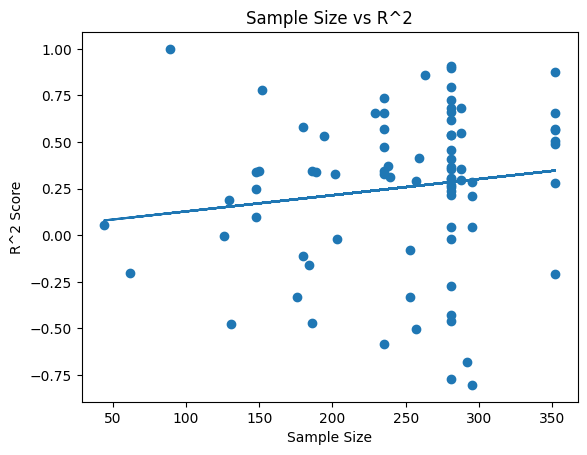

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(data_count_list, r2_list)

plt.xlabel("Sample Size")
plt.ylabel("R^2 Score")
plt.title("Sample Size vs R^2")

plt.show()

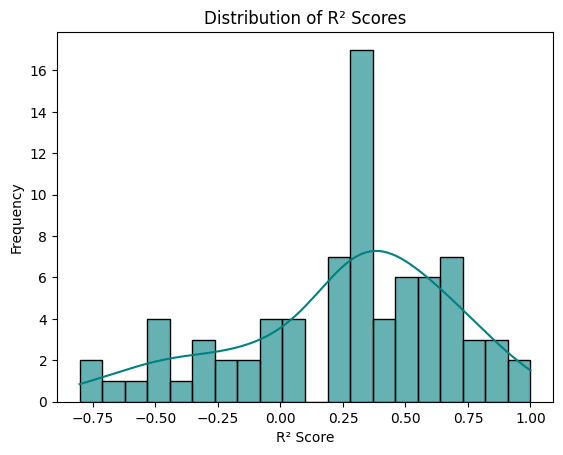

In [54]:
import seaborn as sns

sns.histplot(r2_list, bins=20, kde=True, color='teal', alpha=0.6)

plt.title("Distribution of R² Scores")
plt.xlabel("R² Score")
plt.ylabel("Frequency")

plt.show()

# Testing Number of Lag Days and Window Size

In [21]:
for window_size in [5, 7, 10, 14]:
    for LAG_DAYS in [3, 5, 7]:
        if(LAG_DAYS > window_size):
            continue
        print("Testing for", str(window_size), "day window with" , str(LAG_DAYS), "lag days...") 
        
        mse_list = []
        rmse_list = []
        mae_list = []
        medae_list = []
        maxae_list = []
        mape_list = []
        smape_list = []
        r2_list = []
        evs_list = []
        data_count_list = []
        dropped_rows_list = []
        flagged_list = []
        pooled_pairs = []
        
        for i in range (1, 101):
            file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
            df = pd.read_csv(file_path)
        
            #best solution here - light gbm learns what nan means - Linear Regression doesnt.
            df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
                ["temp_gradient_mean", "setpoint_gap_mean"]
            ].fillna(0)
            
            df = df[lag_worthy_features + same_day_features]
            df = df.dropna()
            
            #filter so that we have the largest group of continuous days not missing values
            df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
            gaps = df[df['day_gap'] != 1]
            groups = (df['day_gap'] > 1).cumsum()
            try:
                largest_group = groups.value_counts().idxmax()
                df = df[groups == largest_group]
            except:
                mse_list.append(0)
                rmse_list.append(np.sqrt(0))
                mae_list.append(0)
                medae_list.append(0)
                maxae_list.append(0)
                mape_list.append(0)
                smape_list.append(0)
                #dummy r^2 value so that the list is filtered out
                r2_list.append(-10)
                evs_list.append(0)
                flagged_list.append(i*100)
                continue
                
        
            lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]
            
            lags = []
            for j in range(1, LAG_DAYS + 1):
            
                s = df[lag_cols_for_shift].shift(j)
            
                s.columns = [f"{c}_lag_{j}" for c in s.columns]
            
                lags.append(s)
            
            df_lags = pd.concat([df] + lags, axis=1)
            
            same_day_feats = [f for f in df_lags.columns if f in same_day_features]
            
            lag_feats = [c for c in df_lags.columns if "_lag_" in c]
            
            day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
            
            final_feature_set = day_only_feats + lag_feats
        
            df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
            
            df_lags_count_initial = len(df_lags)
            df_lags_dropped = df_lags.dropna()
            df_lags_count_final = len(df_lags_dropped)
            dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
            
            dates = df_lags_dropped["Date"]
            X = df_lags_dropped[final_feature_set].drop(columns="Date")
            y = df_lags_dropped["daily_runtime_hours"]
            
            data_count_list.append(len(X))
        
            if len(X) < (window_size * 2):
                mse_list.append(0)
                rmse_list.append(np.sqrt(0))
                mae_list.append(0)
                medae_list.append(0)
                maxae_list.append(0)
                mape_list.append(0)
                smape_list.append(0)
                #dummy r^2 value so that the list is filtered out
                r2_list.append(-10)
                evs_list.append(0)
                flagged_list.append(i)
                continue
            
            windows = []
            
            
            
            for end in range(window_size, len(y) - 1 + 1):
                start = end - window_size
            
                X_train = X[start:end]
                y_train = y[start:end]
                
                X_test = X[end:end + 1]
                y_test = y[end:end + 1]
            
                test_date = dates.iloc[end]
                
                windows.append((X_train, y_train, X_test, y_test, test_date))
        
            predictions = []
            coefs = []
            
            
            for X_train, y_train, X_test, y_test, test_date in windows:
                scaler = StandardScaler()
                
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                
                model = LinearRegression()
                model.fit(X_train_scaled, y_train)
                
                y_pred = model.predict(X_test_scaled)[0]
                
                predictions.append({
                    'y_true': y_test.iloc[0],
                    'y_pred': y_pred,
                    'date': test_date
                })
            
                coefs.append(model.coef_)
            
            avg_coef = np.mean(coefs, axis=0)
            pred_df = pd.DataFrame(predictions)

            pooled_pairs.append((pred_df["y_true"].to_numpy(), pred_df["y_pred"].to_numpy()))
            
            mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
            
            y_true = pred_df["y_true"].to_numpy()
            y_pred = pred_df["y_pred"].to_numpy()
        
            mae = mean_absolute_error(y_true, y_pred)
            medae = np.median(np.abs(y_true - y_pred))
            maxae = np.max(np.abs(y_true - y_pred))
        
            mape_val = mape(y_true, y_pred)
            smape_val = smape(y_true, y_pred)
        
            r2 = r2_score(y_true, y_pred)
            evs = explained_variance_score(y_true, y_pred)
        
            mse_list.append(mse)
            rmse_list.append(np.sqrt(mse))
            mae_list.append(mae)
            medae_list.append(medae)
            maxae_list.append(maxae)
            mape_list.append(mape_val)
            smape_list.append(smape_val)
            r2_list.append(r2)
            evs_list.append(evs)
        
        outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]

        all_metric_lists = {
            "mse": mse_list,
            "rmse": rmse_list,
            "mae": mae_list,
            "medae": medae_list,
            "maxae": maxae_list,
            "mape": mape_list,
            "smape": smape_list,
            "r2": r2_list,
            "evs": evs_list,
            "data-count": data_count_list,
        }
        
        filtered_data = {
            name: [val for i, val in enumerate(lst) if i not in outlier_indices]
            for name, lst in all_metric_lists.items()
        }

        filtered_pairs = [
            pair for i, pair in enumerate(pooled_pairs)
            if i not in outlier_indices
        ]
        
        pooled_y_true = np.concatenate([p[0] for p in filtered_pairs])
        pooled_y_pred = np.concatenate([p[1] for p in filtered_pairs])
        
        pooled_r2 = r2_score(pooled_y_true, pooled_y_pred)
        
        mse_list = filtered_data["mse"]
        rmse_list = filtered_data["rmse"]
        mae_list = filtered_data["mae"]
        medae_list = filtered_data["medae"]
        maxae_list = filtered_data["maxae"]
        mape_list = filtered_data["mape"]
        smape_list = filtered_data["smape"]
        r2_list = filtered_data["r2"]
        evs_list = filtered_data["evs"]
        
        avg_metrics = pd.Series({
            "MSE": np.mean(mse_list),
            "RMSE": np.mean(rmse_list),
            "MAE": np.mean(mae_list),
            "MedianAE": np.mean(medae_list),
            "MaxAE": np.mean(maxae_list),
            "MAPE (%)": np.mean(mape_list),
            "sMAPE (%)": np.mean(smape_list),
            "R2": np.mean(r2_list),
            "Pooled R2": pooled_r2,
            "ExplainedVariance": np.mean(evs_list),
            "Outliers": len(outlier_indices)
        })
        
        print(avg_metrics)

Testing for 5 day window with 3 lag days...
MSE                  1.689506e+01
RMSE                 3.850541e+00
MAE                  2.218827e+00
MedianAE             1.261300e+00
MaxAE                2.755336e+01
MAPE (%)             7.482920e+08
sMAPE (%)            5.542365e+01
R2                   1.527603e-01
Pooled R2            3.540942e-01
ExplainedVariance    1.543854e-01
Outliers             4.100000e+01
dtype: float64
Testing for 5 day window with 5 lag days...
MSE                  1.497191e+01
RMSE                 3.620750e+00
MAE                  2.235312e+00
MedianAE             1.392912e+00
MaxAE                2.274629e+01
MAPE (%)             8.022741e+08
sMAPE (%)            5.588261e+01
R2                   2.366722e-01
Pooled R2            4.152032e-01
ExplainedVariance    2.379754e-01
Outliers             3.500000e+01
dtype: float64
Testing for 7 day window with 3 lag days...
MSE                  1.838850e+01
RMSE                 4.014044e+00
MAE                  2

# Ridge Regression Test

In [74]:
from sklearn.linear_model import Ridge
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []
data_count_list = []
dropped_rows_list = []
flagged_list = []

for i in range (1, 101):
    file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
    df = pd.read_csv(file_path)

    #best solution here - light gbm learns what nan means - Linear Regression doesnt.
    df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
        ["temp_gradient_mean", "setpoint_gap_mean"]
    ].fillna(0)
    
    df = df[lag_worthy_features + same_day_features]
    df = df.dropna()
    
    #filter so that we have the largest group of continuous days not missing values
    df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
    gaps = df[df['day_gap'] != 1]
    groups = (df['day_gap'] > 1).cumsum()
    try:
        largest_group = groups.value_counts().idxmax()
        df = df[groups == largest_group]
    except:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        sample_count_list.append(0)
        flagged_list.append(i*100)
        continue
        

    lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]

    LAG_DAYS = 7
    
    lags = []
    for j in range(1, LAG_DAYS + 1):
    
        s = df[lag_cols_for_shift].shift(j)
    
        s.columns = [f"{c}_lag_{j}" for c in s.columns]
    
        lags.append(s)
    
    df_lags = pd.concat([df] + lags, axis=1)
    
    same_day_feats = [f for f in df_lags.columns if f in same_day_features]
    
    lag_feats = [c for c in df_lags.columns if "_lag_" in c]
    
    day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
    
    final_feature_set = day_only_feats + lag_feats
    
    window_size = 7

    df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
    
    df_lags_count_initial = len(df_lags)
    df_lags_dropped = df_lags.dropna()
    df_lags_count_final = len(df_lags_dropped)
    dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
    
    dates = df_lags_dropped["Date"]
    X = df_lags_dropped[final_feature_set].drop(columns="Date")
    y = df_lags_dropped["daily_runtime_hours"]
    
    data_count_list.append(len(X))

    if len(X) < (window_size * 2):
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        continue
    
    windows = []
    
    
    
    for end in range(window_size, len(y) - 1 + 1):
        start = end - window_size
    
        X_train = X[start:end]
        y_train = y[start:end]
        
        X_test = X[end:end + 1]
        y_test = y[end:end + 1]
    
        test_date = dates.iloc[end]
        
        windows.append((X_train, y_train, X_test, y_test, test_date))

    predictions = []
    coefs = []
    
    
    for X_train, y_train, X_test, y_test, test_date in windows:
        scaler = StandardScaler()
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = Ridge(alpha=1.0)
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)[0]
        
        predictions.append({
            'y_true': y_test.iloc[0],
            'y_pred': y_pred,
            'date': test_date
        })
    
        coefs.append(model.coef_)
    
    avg_coef = np.mean(coefs, axis=0)
    pred_df = pd.DataFrame(predictions)

    mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
    
    y_true = pred_df["y_true"].to_numpy()
    y_pred = pred_df["y_pred"].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)

    

print("Files flagged for null values:", flagged_list)

Files flagged for null values: []


In [75]:
outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]
print(outlier_indices)

[0, 3, 14, 18, 27, 29, 32, 34, 39, 41, 49, 53, 68, 79, 88, 89, 90, 92, 93, 98, 99]


In [76]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list,
    "data-count": data_count_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]
data_count_list = filtered_data["data-count"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
})

print(avg_metrics)

MSE                  1.511355e+01
RMSE                 3.615246e+00
MAE                  2.315690e+00
MedianAE             1.495578e+00
MaxAE                1.973826e+01
MAPE (%)             9.300209e+08
sMAPE (%)            5.740548e+01
R2                   2.818356e-01
ExplainedVariance    2.832833e-01
dtype: float64


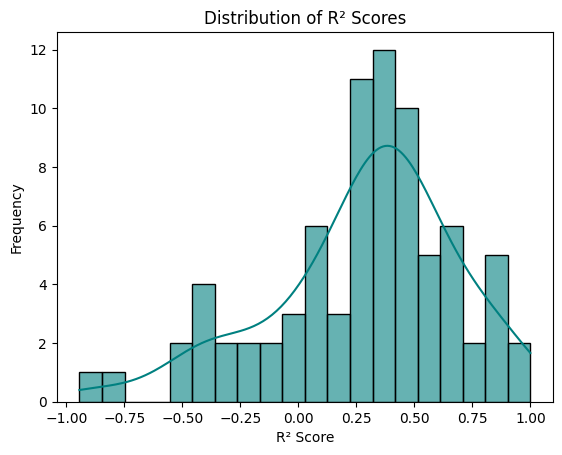

In [77]:
import seaborn as sns

sns.histplot(r2_list, bins=20, kde=True, color='teal', alpha=0.6)

plt.title("Distribution of R² Scores")
plt.xlabel("R² Score")
plt.ylabel("Frequency")

plt.show()